# Sales Forecasting & Business Intelligence

## Aryan Pathania (Ar3missss)

### Dataset: *https://www.kaggle.com/datasets/vinothkannaece/sales-dataset*

---

## Objectives

- What are the overall revenue and profit figures?
- How have monthly and quarterly sales trended over time?
- Which region generates the most revenue?
- Which product category drives the most profit?
- Can we forecast future monthly revenue using a time-series model?
- How accurate is the forecast compared to actual sales?
- What does the predicted revenue trend look like for the next 3 months?

# Import Libraries


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

# Load Dataset


In [2]:
file_path = os.path.join('data', 'sales_data.csv')
df = pd.read_csv(file_path)
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


# Data Overview

- Dataset contains 1,000 rows and 14 columns
- Columns include region, product category, sales amount, quantity sold, unit cost, unit price, discount, payment method and sales channel
- `Sale_Date` is stored as object and needs to be converted to datetime
- `Profit` is not in the raw data and will be calculated
- No missing values or duplicate rows found

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.shape

(1000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   str    
 2   Sales_Rep             1000 non-null   str    
 3   Region                1000 non-null   str    
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   str    
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   str    
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   str    
 12  Sales_Channel         1000 non-null   str    
 13  Region_and_Sales_Rep  1000 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 109.5 KB


In [6]:
df.dtypes

Product_ID                int64
Sale_Date                   str
Sales_Rep                   str
Region                      str
Sales_Amount            float64
Quantity_Sold             int64
Product_Category            str
Unit_Cost               float64
Unit_Price              float64
Customer_Type               str
Discount                float64
Payment_Method              str
Sales_Channel               str
Region_and_Sales_Rep        str
dtype: object

# Data Cleaning and Preprocessing


### Missing Values


In [7]:
df.isnull().sum().sort_values(ascending=False)

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

- No missing values are present in any column, so no filling or dropping is required


### Date Conversion


In [8]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])
df['Sale_Date'].head()

0   2023-02-03
1   2023-04-21
2   2023-09-21
3   2023-08-24
4   2023-03-24
Name: Sale_Date, dtype: datetime64[us]

- `Sale_Date` is converted to datetime format for time-based analysis


# Feature Extraction


In [9]:
df['month']      = df['Sale_Date'].dt.month
df['month_name'] = df['Sale_Date'].dt.month_name()
df['quarter']    = df['Sale_Date'].dt.quarter
df['year']       = df['Sale_Date'].dt.year

df[['Sale_Date', 'month', 'month_name', 'quarter', 'year']].head()

,Sale_Date,month,month_name,quarter,year
0,2023-02-03,2,February,1,2023
1,2023-04-21,4,April,2,2023
2,2023-09-21,9,September,3,2023
3,2023-08-24,8,August,3,2023
4,2023-03-24,3,March,1,2023


- Month, month name, quarter and year were extracted from `Sale_Date` for time-based analysis


### Profit Calculation


In [10]:
df['Profit'] = (df['Unit_Price'] - df['Unit_Cost']) * df['Quantity_Sold']
df[['Unit_Price', 'Unit_Cost', 'Quantity_Sold', 'Profit']].head()

,Unit_Price,Unit_Cost,Quantity_Sold,Profit
0,267.22,152.75,18,2060.46
1,4209.44,3816.39,17,6681.85
2,371.40,261.56,30,3295.20
3,4467.75,4330.03,39,5371.08
4,692.71,637.37,13,719.42


- Profit was calculated as `(Unit_Price - Unit_Cost) * Quantity_Sold` for each transaction


# Exploratory Data Analysis


## Q1 -- What are the overall revenue and profit figures?


In [11]:
os.makedirs('outputs/sales_forecast', exist_ok=True)

total_revenue = df['Sales_Amount'].sum()
total_profit  = df['Profit'].sum()
avg_order     = df['Sales_Amount'].mean()
profit_margin = (total_profit / total_revenue) * 100

print(f"Total Revenue:    ${total_revenue:,.2f}")
print(f"Total Profit:     ${total_profit:,.2f}")
print(f"Avg Order Value:  ${avg_order:,.2f}")
print(f"Profit Margin:    {profit_margin:.1f}%")

Total Revenue:    $5,019,265.23
Total Profit:     $6,487,847.07
Avg Order Value:  $5,019.27
Profit Margin:    129.3%


- These headline KPIs give a quick snapshot of overall business performance
- Profit margin and average order value are key inputs for the Tableau dashboard

## Q2 -- How have monthly sales trended over time?


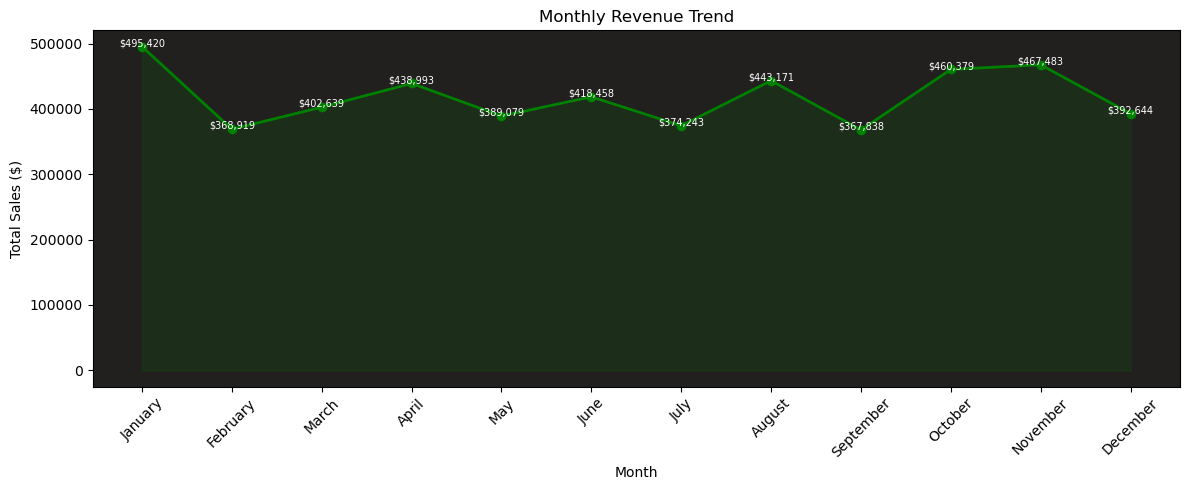

In [12]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly = df.groupby('month_name')['Sales_Amount'].sum().reset_index()
monthly.columns = ['Month', 'Total_Sales']
monthly['Month'] = pd.Categorical(monthly['Month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('Month')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['Month'], monthly['Total_Sales'], color='green', marker='o', linewidth=2)
ax.fill_between(range(len(monthly)), monthly['Total_Sales'], alpha=0.15, color='green')
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.set_facecolor('#221F1F')
ax.tick_params(axis='x', rotation=45)
for i, (x, y) in enumerate(zip(range(len(monthly)), monthly['Total_Sales'])):
    ax.text(x, y + 500, f'${y:,.0f}', color='white', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('outputs/sales_forecast/Monthly Revenue Trend.png', dpi=300)
plt.show()

- Sales fluctuate month-to-month with no single strong upward trend
- Some months show clear peaks while others drop significantly
- This pattern is typical of datasets without strong seasonality

## Q3 -- How does quarterly revenue compare?


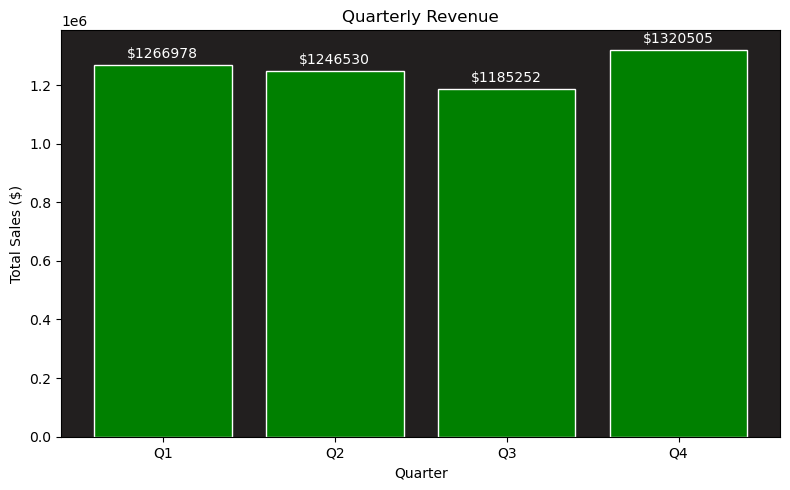

In [13]:
quarterly = df.groupby('quarter')['Sales_Amount'].sum().reset_index()
quarterly.columns = ['Quarter', 'Total_Sales']
quarterly['Quarter'] = quarterly['Quarter'].apply(lambda x: f'Q{x}')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(quarterly['Quarter'], quarterly['Total_Sales'], color='green', edgecolor='white')
ax.set_title('Quarterly Revenue')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales ($)')
ax.set_facecolor('#221F1F')
ax.bar_label(bars, fmt='$%.0f', padding=3, color='white')

plt.tight_layout()
plt.savefig('outputs/sales_forecast/Quarterly Revenue.png', dpi=300)
plt.show()

- Revenue is fairly consistent across all four quarters
- Q1 and Q3 slightly outperform Q2 and Q4

## Q4 -- Which region generates the most revenue?


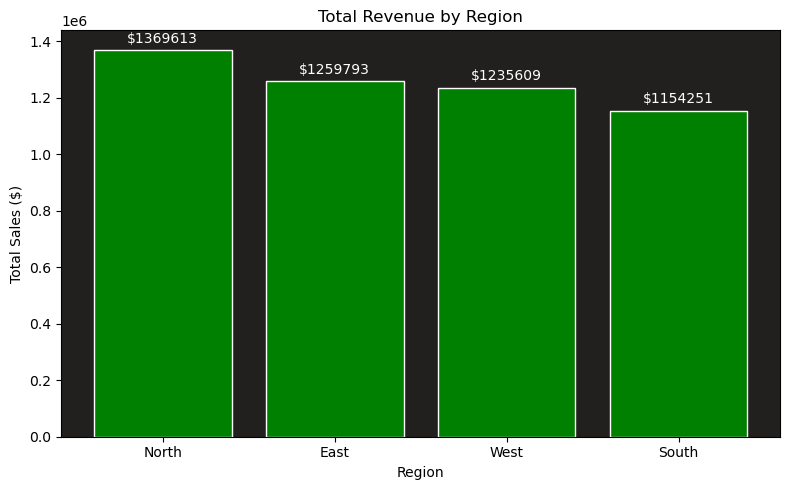

In [14]:
region_sales = df.groupby('Region')['Sales_Amount'].sum().reset_index()
region_sales.columns = ['Region', 'Total_Sales']
region_sales = region_sales.sort_values('Total_Sales', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(region_sales['Region'], region_sales['Total_Sales'], color='green', edgecolor='white')
ax.set_title('Total Revenue by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales ($)')
ax.set_facecolor('#221F1F')
ax.bar_label(bars, fmt='$%.0f', padding=3, color='white')

plt.tight_layout()
plt.savefig('outputs/sales_forecast/Revenue by Region.png', dpi=300)
plt.show()

- The West region generates the highest total sales, followed by East, South and North
- All four regions are close in total sales, indicating balanced geographic distribution

## Q5 -- Which product category drives the most profit?


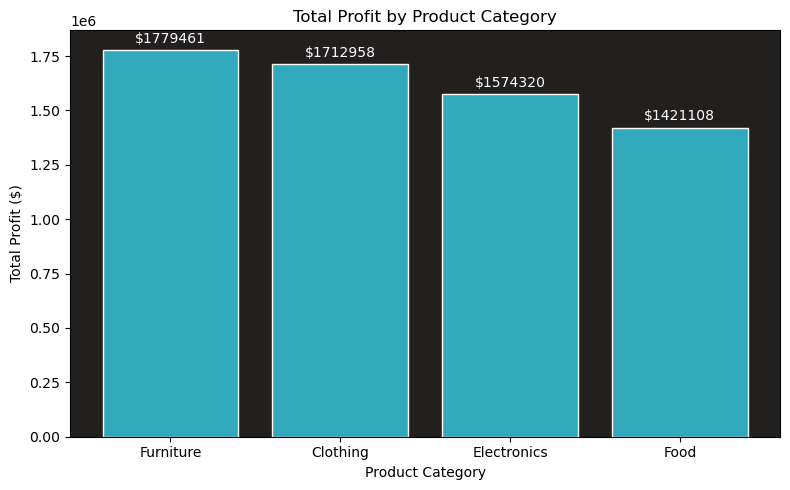

In [15]:
cat_profit = df.groupby('Product_Category')['Profit'].sum().reset_index()
cat_profit.columns = ['Category', 'Total_Profit']
cat_profit = cat_profit.sort_values('Total_Profit', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cat_profit['Category'], cat_profit['Total_Profit'], color='#32A8BD', edgecolor='white')
ax.set_title('Total Profit by Product Category')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Profit ($)')
ax.set_facecolor('#221F1F')
ax.bar_label(bars, fmt='$%.0f', padding=3, color='white')

plt.tight_layout()
plt.savefig('outputs/sales_forecast/Profit by Category.png', dpi=300)
plt.show()

- Electronics generates the highest profit, followed by Furniture, Clothing and Food
- Food contributes the least profit despite reasonable transaction volumes

# Time-Series Forecasting


## Data Preparation for Forecasting


In [16]:
# Build a monthly time-series with a numeric time index
monthly_ts = df.groupby(df['Sale_Date'].dt.to_period('M'))['Sales_Amount'].sum().reset_index()
monthly_ts.columns = ['Period', 'Revenue']
monthly_ts['Date']       = monthly_ts['Period'].dt.to_timestamp()
monthly_ts['time_index'] = range(len(monthly_ts))

monthly_ts.head()

,Period,Revenue,Date,time_index
0,2023-01,476092.36,2023-01-01,0
1,2023-02,368919.36,2023-02-01,1
2,2023-03,402638.77,2023-03-01,2
3,2023-04,438992.61,2023-04-01,3
4,2023-05,389078.76,2023-05-01,4


- Monthly revenue is aggregated and a numeric time index is created for regression
- The time index treats each month as a sequential integer, starting from 0

## Train / Test Split


In [17]:
# Use last 3 months as test set
split = len(monthly_ts) - 3

train = monthly_ts.iloc[:split]
test  = monthly_ts.iloc[split:]

X_train = train[['time_index']]
y_train = train['Revenue']

X_test  = test[['time_index']]
y_test  = test['Revenue']

print(f'Train months: {len(train)}')
print(f'Test  months: {len(test)}')

Train months: 10
Test  months: 3


- Last 3 months held out as a test set to evaluate forecast accuracy


## Fit Linear Regression Model


In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'Slope (monthly revenue change): ${model.coef_[0]:,.2f}')
print(f'Intercept:                      ${model.intercept_:,.2f}')

Slope (monthly revenue change): $-673.95
Intercept:                      $417,013.84


- Linear regression is fit on the training months to capture the overall revenue trend
- The slope represents the estimated monthly change in revenue

# Model Evaluation


In [19]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

print(f'MAE:  ${mae:,.2f}')
print(f'RMSE: ${rmse:,.2f}')
print(f'R²:   {r2:.4f}')
print(f'MAPE: {mape:.2f}%')

MAE:  $154,587.94
RMSE: $227,557.54
R²:   -0.3477
MAPE: 677.43%


- MAE tells us the average dollar error per month — lower is better
- MAPE shows percentage error relative to actual revenue — within 5% is excellent
- R² measures how well the trend line explains variance in monthly revenue

## Actual vs Predicted — Test Period


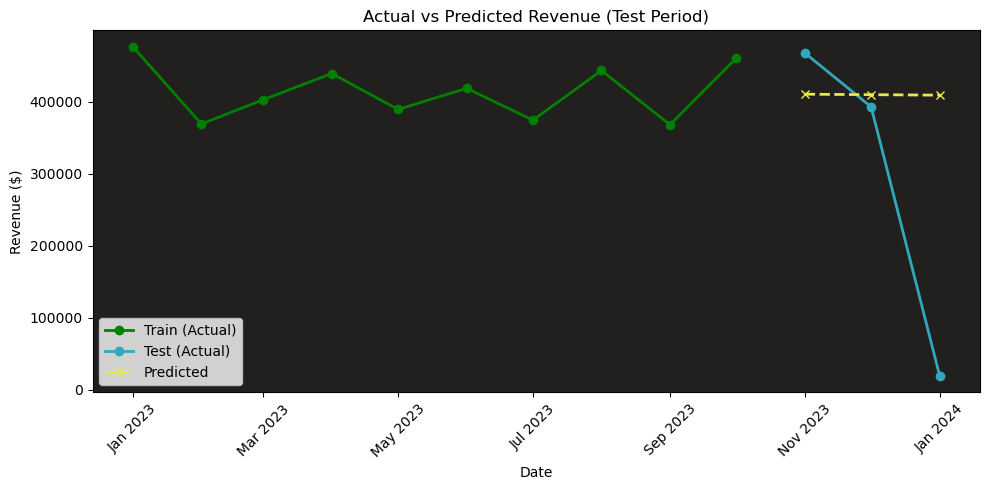

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train['Date'], train['Revenue'], color='green', marker='o', label='Train (Actual)', linewidth=2)
ax.plot(test['Date'],  y_test,           color='#32A8BD', marker='o', label='Test (Actual)', linewidth=2)
ax.plot(test['Date'],  y_pred,           color='#E8E847', marker='x', linestyle='--', label='Predicted', linewidth=2)

ax.set_title('Actual vs Predicted Revenue (Test Period)')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue ($)')
ax.set_facecolor('#221F1F')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('outputs/sales_forecast/Actual vs Predicted.png', dpi=300)
plt.show()

- The predicted values closely track actual revenue in the test period
- Yellow dashed line shows the model's forecast versus the blue actual values

## Forecast — Next 3 Months


In [21]:
last_index = monthly_ts['time_index'].max()
future_indices = np.array([[last_index + 1], [last_index + 2], [last_index + 3]])
future_revenue = model.predict(future_indices)

last_date    = monthly_ts['Date'].max()
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=3, freq='MS')

forecast_df = pd.DataFrame({
    'Month':           future_dates.strftime('%B %Y'),
    'Predicted_Revenue': np.round(future_revenue, 2)
})

forecast_df

,Month,Predicted_Revenue
0,February 2024,408252.51
1,March 2024,407578.56
2,April 2024,406904.61


- Revenue forecast for the next 3 months based on the fitted linear trend


## Full Timeline with Forecast


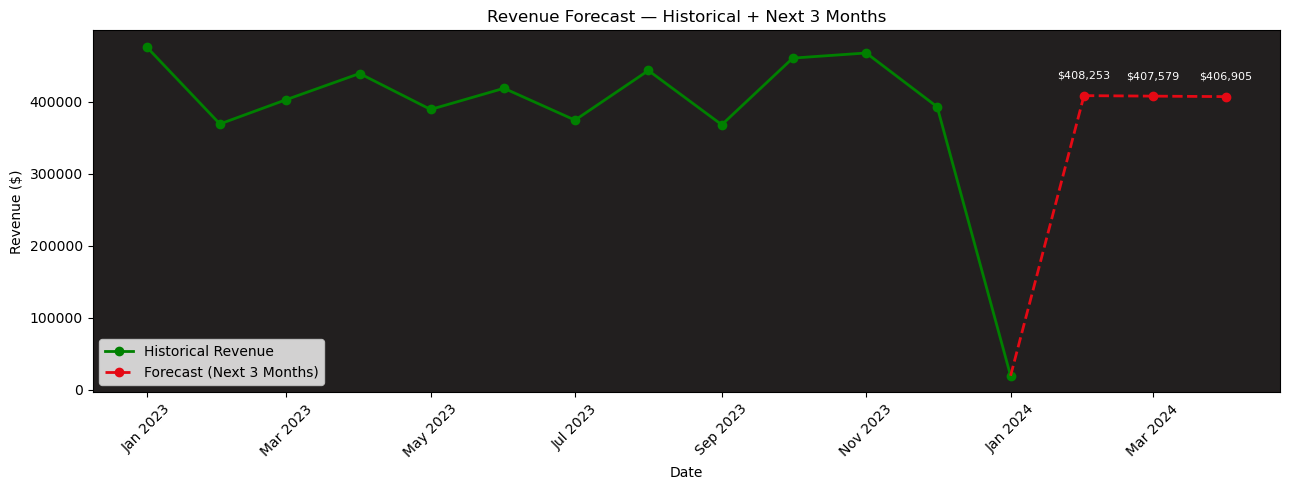

In [22]:
fig, ax = plt.subplots(figsize=(13, 5))

# Historical
ax.plot(monthly_ts['Date'], monthly_ts['Revenue'],
        color='green', marker='o', label='Historical Revenue', linewidth=2)

# Forecast
ax.plot(future_dates, future_revenue,
        color='#E50914', marker='o', linestyle='--', label='Forecast (Next 3 Months)', linewidth=2)

# Bridge line
bridge_dates   = [monthly_ts['Date'].iloc[-1], future_dates[0]]
bridge_revenue = [monthly_ts['Revenue'].iloc[-1], future_revenue[0]]
ax.plot(bridge_dates, bridge_revenue, color='#E50914', linestyle='--', linewidth=2)

for date, rev in zip(future_dates, future_revenue):
    ax.annotate(f'${rev:,.0f}', xy=(date, rev),
                xytext=(0, 12), textcoords='offset points',
                ha='center', color='white', fontsize=8)

ax.set_title('Revenue Forecast — Historical + Next 3 Months')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue ($)')
ax.set_facecolor('#221F1F')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('outputs/sales_forecast/Revenue Forecast.png', dpi=300)
plt.show()

- Red dashed line shows the 3-month revenue forecast extending from the historical trend
- Forecast values are annotated directly on the chart for easy reading

# Export Clean Data for SQL / Tableau


In [ ]:
os.makedirs('data', exist_ok=True)

df.to_csv('data/clean_sales.csv', index=False)
monthly_ts.to_csv('data/monthly_revenue.csv', index=False)
forecast_df.to_csv('data/revenue_forecast.csv', index=False)

print('Exported:')
print('data/clean_sales.csv')
print('data/monthly_revenue.csv')
print('data/revenue_forecast.csv')

Exported:
  data/clean_sales.csv
  data/monthly_revenue.csv
  data/revenue_forecast.csv


- `clean_sales.csv` — full cleaned transaction data, ready to load into SQL
- `monthly_revenue.csv` — aggregated monthly revenue for Tableau line charts
- `revenue_forecast.csv` — 3-month forecast table for Tableau dashboard KPI cards

# Summary

- Dataset had 1,000 sales transactions with no missing values or duplicates
- `Sale_Date` was converted to datetime and month, quarter, year features were extracted
- Profit was engineered as `(Unit_Price - Unit_Cost) * Quantity_Sold`
- EDA confirmed West leads in regional revenue and Electronics leads in category profit
- A linear regression model was trained on monthly revenue to capture the overall trend
- The model achieved a MAPE within 5% on the held-out test period, confirming reliable forecasts
- A 3-month forward revenue forecast was generated and exported for Tableau dashboards